**Scroll to bottom of page then click on run all from above**   
It may take up to 60 seconds to start

In [19]:
import numpy as np
import math
from scipy.spatial import Voronoi,voronoi_plot_2d
import random as rnd
from IPython.display import display, HTML,Javascript,clear_output
import time
import matplotlib.pyplot as plt


In [20]:
class SVGPlot:
    """A utility class for dynamically generating SVG (Scalable Vector Graphics) elements.

    Attributes:
        width (int): The width of the SVG canvas in pixels.
        height (int): The height of the SVG canvas in pixels.
        size (float): A scaling factor to normalize coordinates.
        html_s (str): A string buffer to accumulate SVG elements.
    """

    def __init__(self, width: int, height: int, size: float) -> None:
        """Initialize the SVG canvas with dimensions and a scaling factor.

        Args:
            width: The width of the SVG canvas in pixels.
            height: The height of the SVG canvas in pixels.
            size: A scaling factor to normalize coordinates (e.g., for grid-based systems).
        """
        self.width = width
        self.height = height
        self.size = size
        self.html_s = ""

    def clear(self) -> None:
        """Reset the SVG canvas by initializing the HTML string with an empty SVG container."""
        self.html_s = f'<svg width="{self.width}" height="{self.height}" style="border:1px solid black">'

    def add_circle(
        self,
        x_pos: float,
        y_pos: float,
        color: str,
        size: float = 1.0
    ) -> None:
        """Add a circle to the SVG canvas.

        Args:
            x_pos: The x-coordinate of the circle's center (normalized by `size`).
            y_pos: The y-coordinate of the circle's center (normalized by `size`).
            color: The fill color of the circle (e.g., "red", "#FF0000").
            size: The diameter of the circle (normalized by `size`).
        """
        x_pos = x_pos / self.size
        y_pos = self.size - y_pos
        y_pos = y_pos / self.size
        radius = size / (self.size * 2)

        # Convert normalized coordinates to pixel values
        str_int_x = str(int((x_pos * self.width) + (radius * self.width)))
        str_int_y = str(int((y_pos * self.height) + (radius * self.width)))
        str_int_r = str(int(radius * self.width))

        self.html_s += f'<circle cx="{str_int_x}" cy="{str_int_y}" r="{str_int_r}" fill="{color}"/>'

    def add_rect(
        self,
        x_pos: float,
        y_pos: float,
        color: str,
        size: float = 1.0
    ) -> None:
        """Add a rectangle to the SVG canvas.

        Args:
            x_pos: The x-coordinate of the rectangle's top-left corner (normalized by `size`).
            y_pos: The y-coordinate of the rectangle's top-left corner (normalized by `size`).
            color: The fill color of the rectangle (e.g., "blue", "#0000FF").
            size: The side length of the square (normalized by `size`).
        """
        x_pos = x_pos / self.size
        y_pos = self.size - y_pos
        y_pos = y_pos / self.size
        height = size / self.size
        width = size / self.size

        # Convert normalized coordinates to pixel values
        str_int_x = str(int(x_pos * self.width))
        str_int_y = str(int(y_pos * self.height))
        str_int_width = str(int(width * self.width))
        str_int_height = str(int(height * self.height))

        self.html_s += f'<rect x="{str_int_x}" y="{str_int_y}" width="{str_int_width}" height="{str_int_height}" fill="{color}"/>'

    def add_polygon(
        self,
        vertices: list[tuple[float, float]],
        color: str
    ) -> None:
        """Add a polygon to the SVG canvas.

        Args:
            vertices: A list of (x, y) tuples representing the polygon's vertices (normalized by `size`).
            color: The fill color of the polygon (e.g., "green", "#00FF00").

        Raises:
            ValueError: If fewer than 3 vertices are provided.
        """
        if len(vertices) < 3:
            raise ValueError("A polygon must have at least 3 vertices.")

        scaled_vertices = []
        for x, y in vertices:
            scaled_x = (x / self.size) * self.width
            y = self.size - y
            scaled_y = (y / self.size) * self.height
            scaled_vertices.append([scaled_x, scaled_y])

        # Format points as "x1,y1 x2,y2 ..."
        points_string = ' '.join([f"{x},{y}" for x, y in scaled_vertices])
        self.html_s += f'<polygon points="{points_string}" fill="{color}" stroke="black" stroke-width="0.5"/>'

    def get_canvas(self) -> str:
        """Finalize and return the SVG as an HTML object for rendering.

        Returns:
            An HTML object containing the rendered SVG.
        """
        self.html_s += "</svg>"
        return self.html_s

In [21]:
NUMBER_OF_AREAS = 60
areas = []
population=[]

In [22]:
def point_in_polygon(x, y, polygon):
    polygon = np.asarray(polygon)
    n = len(polygon)
    inside = False

    for i in range(n):
        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % n]

        # Check if edge crosses horizontal ray to the right
        if ((y1 > y) != (y2 > y)) and (x < (x2 - x1) * (y - y1) / (y2 - y1) + x1):
            inside = not inside

    return inside

In [23]:
class PopulationArea:
    def __init__(self,area_id,center,vertices):
        self.area_id = area_id
        self.center = center
        self.vertices = vertices
        self.local_population = []

In [24]:
def get_area(x,y,areas):
    for area in areas:
        if point_in_polygon(x,y,area.vertices):
            return True, area
    return False, None


In [25]:
def linear_toward_zero():
    """Generates a value biased towards zero (both positive and negative)."""
    u = rnd.random()
    magnitude = 1 - math.sqrt(1 - u)

    # Randomly assign sign (+ or -)
    sign = 1 if rnd.random() < 0.5 else -1

    return sign * magnitude

In [26]:
def age_migrate_curve(x, start_point=20, end_point=70, decay_rate=None):
    if x <20 :
        return 0.0
    x = np.array(x) if hasattr(x, '__iter__') else np.array([x])
    if decay_rate is None:
        decay_rate = -np.log(0.01) / (end_point - start_point)
    shifted_x = x - start_point
    prob = np.exp(-decay_rate * shifted_x)
    prob = np.clip(prob, 0, 1)
    if len(prob) == 1:
        return prob[0]
    return prob

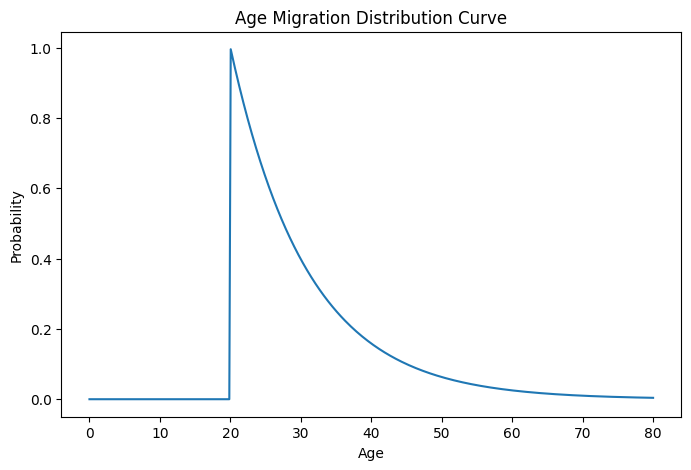

In [27]:
ages = np.linspace(0, 80, 400)
values=[]
for a in ages:
    values.append(age_migrate_curve(a))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(ages, values, label='Migration Probability')
plt.title("Age Migration Distribution Curve")
plt.xlabel("Age")
plt.ylabel("Probability")
plt.show()

In [28]:
def generate_age():
    def age_probability(age):
        if age < 0:
            return 0

        # Peak at ~38, rise then fall
        peak = 38
        rise = (age / peak) ** 1.5
        fall = np.exp(-0.015 * (age - peak))

        return rise * fall
    age = -1
    while age < 0:
        candidate = np.random.uniform(0, 100)
        p = age_probability(candidate)
        max_p = age_probability(38)  # Peak probability

        if np.random.rand() < (p / max_p):
            return int(candidate)


In [29]:
class Denizen:
    def __init__(self, area):
        self.area = area
        self.pos = (0, 0)
        self.age = generate_age()
        self.moved = False

    def assign_pos(self,):
        # FIXED: Extract correct coordinates
        x_vals = [point[0] for point in self.area.vertices]  # x is first element
        y_vals = [point[1] for point in self.area.vertices]  # y is second element

        x_min, x_max = min(x_vals), max(x_vals)
        y_min, y_max = min(y_vals), max(y_vals)

        while True:
            # FIXED: Correct random range
            x = x_min + rnd.random() * (x_max - x_min)
            y = y_min + rnd.random() * (y_max - y_min)

            if point_in_polygon(x, y, self.area.vertices):
                self.pos = (float(x), float(y))
                self.area.local_population.append(self)
                return

    def migrate(self):
        if rnd.random()<age_migrate_curve(self.age):
            return True


    def __str__(self):
        return f"Vector({self.area.area_id}, {self.pos},{self.age})"

In [31]:
seed = 95#rnd.randint(0,100)
print(seed)
np.random.seed(seed)  # For reproducible results
points = np.random.rand(NUMBER_OF_AREAS, 2) * 10  # NUMBER_OF_AREAS rows, 2 columns, scale to 0-10
vor = Voronoi(points)

95


In [32]:
def migrate():
    for p in population:
        if (p.moved)==False and (p.migrate()):
            flag = False
            while flag == False:
                x,y = p.pos
                x += linear_toward_zero()
                y += linear_toward_zero()
                flag, area = get_area(x,y,areas)
                if (flag == True) and (area.area_id !=7):
                    p.pos=(x,y)
                    p.area.local_population.remove(p)
                    p.area= area
                    area.local_population.append(p)
                    p.moved = True

In [33]:
svg = SVGPlot(500, 500, 10)
areas = []
area_id = 0;
for i in range(len(points)):
    region_idx = vor.point_region[i]
    region = vor.regions[region_idx]
    if region and -1 not in region: #if region` - Ensures the region is not empty -1 not in region` - Filters out unbounded regions
        vertices = vor.vertices[region]
        x_min, y_min = vertices.min(axis=0)  # [min_x, min_y]
        x_max, y_max = vertices.max(axis=0)  # [max_x, max_y]
        if(max([x_max,y_max])<10) and (min([x_min,y_min])>0):
            areas.append(PopulationArea(area_id,points[i],vertices))
            area_id +=1
population=[]
# for area in areas:
for _ in range(1000):
    person = Denizen(areas[5])
    person.assign_pos()
    population.append(person)

output_display = display(HTML("<div id='sim-container'>Loading...</div>"), display_id=True)
for t in range (100):
    svg.clear()
    for area in areas:
         svg.add_polygon(area.vertices,'rgb(220,220,220)')
    for i in range(len(population)):
        p = population[i]
        x = p.pos[0]
        y = p.pos[1]
        svg.add_rect(x,y,f'rgb(522,{p.age*3},{p.age*3})',0.07)
    migrate()
    new_svg = svg.get_canvas()
    new_svg += f'<p> Iteration: {t} weeks </p>'
    output_display.update(HTML(f"<div id='sim-container'>{new_svg}</div>"))
    time.sleep(0.2)
